Using features: ['Trade_Balance_2023', 'Growth_2019_2023', 'Growth_2022_2023', 'World_Growth', 'World_Import_Rank', 'Avg_Distance_km', 'Concentration', 'World_Import_Share', 'Avg_Tariff', 'Country', 'Product', 'Direction']
Log-transform numeric features: ['Concentration', 'World_Import_Share', 'Avg_Tariff']
Log-transform TARGET: True

Holdout metrics:
Linear Regression  | R2=0.9068  RMSE=1316988.2034  MAE=213664.2413  MAPE%=56.39
XGBoost            | R2=0.8927  RMSE=1413026.6279  MAE=201624.5860  MAPE%=69.19


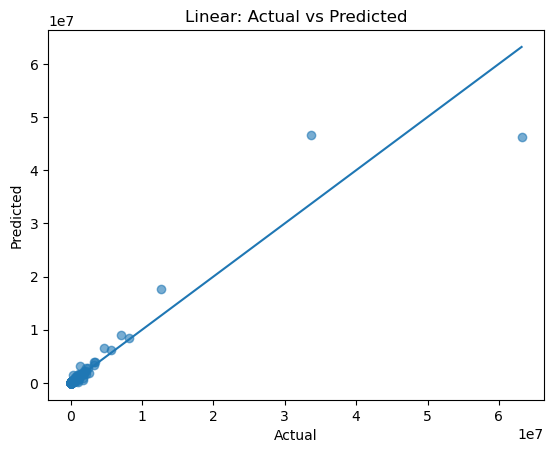

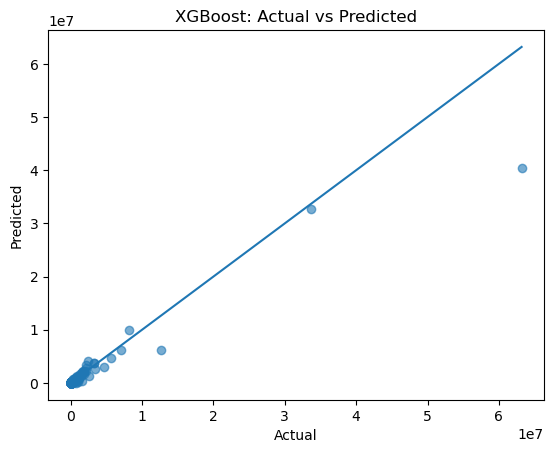

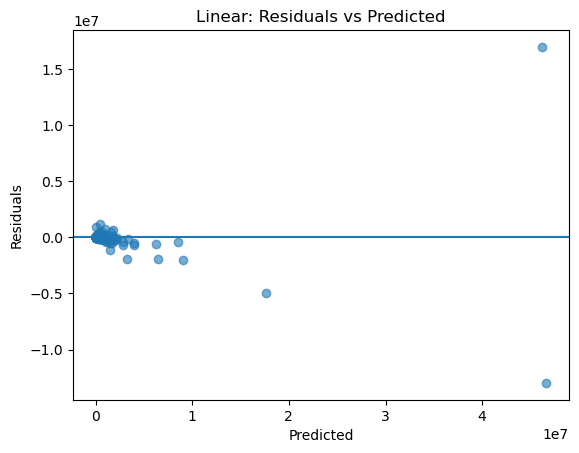

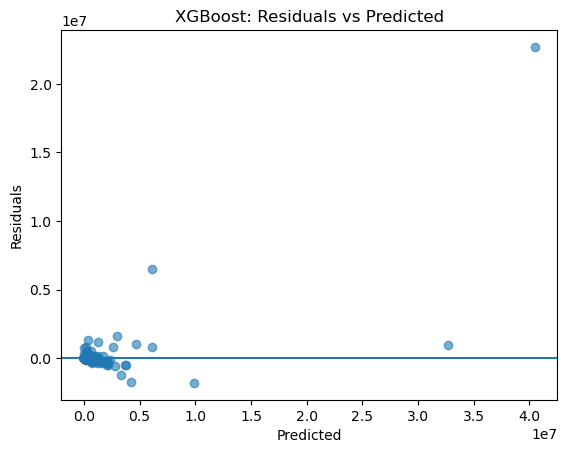

In [12]:
# ==============================================================
# Clean Preprocessing + Feature Selection + Log-Transforms
# Compare Linear Regression vs XGBoost with Inline Plots
# ==============================================================

# ------------ Config ------------
CSV_PATH = "cleaned_trade_master (1).csv" 
RANDOM_STATE = 42
TEST_SIZE = 0.2
CORR_THRESHOLD = 0.05     # keeping numeric features with |Spearman corr| 
SKEW_THRESHOLD = 1.0      # log1p-transform numeric features with skewness 

# ------------ Imports ------------
import warnings, math, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import TransformedTargetRegressor
from scipy.stats import spearmanr

try:
    from xgboost import XGBRegressor
except Exception as e:
    raise ImportError("XGBoost is required. Install with `pip install xgboost`.") from e

warnings.filterwarnings("ignore")
np.random.seed(RANDOM_STATE)

# ------------ 1) Loading data  &  Cleaning data ------------
df = pd.read_csv(CSV_PATH)

# Normalizing column names
df.columns = [c.strip() for c in df.columns]

if "Value_2023" not in df.columns:
    raise ValueError("Column 'Value_2023' not found. Please check your file.")

# Dropping exact duplicate columns 
df = df.loc[:, ~df.columns.duplicated()].copy()

# Converting likely numeric columns to numeric (safe)
def to_numeric_safe(s):
    return pd.to_numeric(s, errors="coerce")

numeric_guess = []
for c in df.columns:
    if c == "Value_2023": 
        numeric_guess.append(c)
    elif any(k in c.lower() for k in ["value", "growth", "rank", "distance", "tariff", "balance", "share", "concentration", "world"]):
        numeric_guess.append(c)

for c in numeric_guess:
    if c in df.columns:
        df[c] = to_numeric_safe(df[c])

# Removing rows with missing target
df = df.dropna(subset=["Value_2023"]).copy()

# ------------ 2) Feature Set (auto-select "useful" ones) ------------

cat_candidates = [c for c in ["Country","Product","Direction"] if c in df.columns]

num_candidates = [c for c in [
    "Trade_Balance_2023","Growth_2019_2023","Growth_2022_2023",
    "World_Growth","World_Import_Rank","Avg_Distance_km",
    "Concentration","World_Import_Share","Avg_Tariff"
] if c in df.columns]

# Spearman correlation filter on numeric features
def spearman_abs_corr(x, y):
    mask = x.notna() & y.notna()
    if mask.sum() < 10:
        return 0.0
    r, _ = spearmanr(x[mask], y[mask])
    return abs(0.0 if np.isnan(r) else r)

target = "Value_2023"
num_kept = []
for c in num_candidates:
    rabs = spearman_abs_corr(df[c], df[target])
    if rabs >= CORR_THRESHOLD:
        num_kept.append(c)

# If nothing passes, keeping original numeric candidates to avoid empty
if not num_kept:
    num_kept = num_candidates.copy()

features = num_kept + cat_candidates
print("Using features:", features)

# ------------ 3) Train / Test Split ------------
X = df[features].copy()
y = df[target].astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

# ------------ 4) Detecting Skew: Numeric features & Target ------------
# Preparing a temp-imputed copy to measure skew robustly
X_num = X_train[num_kept].copy() if num_kept else pd.DataFrame(index=X_train.index)
for c in X_num.columns:
    X_num[c] = X_num[c].fillna(X_num[c].median())

# Identifying skewed & non-negative numeric columns for log1p
log_num_cols = []
for c in X_num.columns:
    col = X_num[c]
    if (col.min() >= 0) and (abs(col.skew(skipna=True)) > SKEW_THRESHOLD):
        log_num_cols.append(c)

# Targeting skew check (log-transform target if heavily skewed & non-negative)
use_log_target = (y_train.min() >= 0) and (abs(pd.Series(y_train).skew()) > SKEW_THRESHOLD)
print(f"Log-transform numeric features: {log_num_cols}")
print(f"Log-transform TARGET: {use_log_target}")

# Spliting numeric features into two groups (log vs not)
num_nonlog_cols = [c for c in num_kept if c not in log_num_cols]

# ------------ 5) Preprocessing Pipelines ------------
# numeric (log)
num_log_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
    ("scaler", StandardScaler())
])

# numeric (non-log)
num_plain_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# categorical
cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# ColumnTransformer with optional groups
transformers = []
if num_nonlog_cols:
    transformers.append(("num", num_plain_pipe, num_nonlog_cols))
if log_num_cols:
    transformers.append(("num_log", num_log_pipe, log_num_cols))
if cat_candidates:
    transformers.append(("cat", cat_pipe, cat_candidates))

preprocessor = ColumnTransformer(transformers)

# ------------ 6) Models ------------
linreg = Pipeline([
    ("prep", preprocessor),
    ("model", LinearRegression())
])

xgb = Pipeline([
    ("prep", preprocessor),
    ("model", XGBRegressor(
        n_estimators=400, max_depth=6, learning_rate=0.06,
        subsample=0.9, colsample_bytree=0.9,
        reg_lambda=1.0, random_state=RANDOM_STATE, tree_method="hist"
    ))
])

# Optionally wrapping  with log-target if skewed
if use_log_target:
    linreg = TransformedTargetRegressor(regressor=linreg, func=np.log1p, inverse_func=np.expm1)
    xgb   = TransformedTargetRegressor(regressor=xgb,   func=np.log1p, inverse_func=np.expm1)

# ------------ 7) Fit & Predict ------------
linreg.fit(X_train, y_train)
xgb.fit(X_train, y_train)

pred_lr  = linreg.predict(X_test)
pred_xgb = xgb.predict(X_test)

# ------------ 8) Metrics ------------
def metrics(y_true, y_pred):
    r2   = r2_score(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    denom = np.where(y_true==0, np.nan, y_true)
    mape = float(np.nanmean(np.abs((y_true - y_pred) / denom)) * 100.0)
    return {"R2": r2, "RMSE": rmse, "MAE": mae, "MAPE%": mape}

m_lr  = metrics(y_test.values, pred_lr)
m_xgb = metrics(y_test.values, pred_xgb)

print("\nHoldout metrics:")
for name, m in [("Linear Regression", m_lr), ("XGBoost", m_xgb)]:
    print(f"{name:18s} | R2={m['R2']:.4f}  RMSE={m['RMSE']:.4f}  MAE={m['MAE']:.4f}  MAPE%={m['MAPE%']:.2f}")


# (B) Actual vs Predicted (two figures)
plt.figure()
plt.scatter(y_test.values, pred_lr, alpha=0.6)
lims = [min(y_test.min(), pred_lr.min()), max(y_test.max(), pred_lr.max())]
plt.plot(lims, lims)
plt.title("Linear: Actual vs Predicted"); plt.xlabel("Actual"); plt.ylabel("Predicted")
plt.show()

plt.figure()
plt.scatter(y_test.values, pred_xgb, alpha=0.6)
lims = [min(y_test.min(), pred_xgb.min()), max(y_test.max(), pred_xgb.max())]
plt.plot(lims, lims)
plt.title("XGBoost: Actual vs Predicted"); plt.xlabel("Actual"); plt.ylabel("Predicted")
plt.show()

# (C) Residuals vs Predicted (two figures)
res_lr  = y_test.values - pred_lr
res_xgb = y_test.values - pred_xgb

plt.figure()
plt.scatter(pred_lr, res_lr, alpha=0.6)
plt.axhline(0)
plt.title("Linear: Residuals vs Predicted"); plt.xlabel("Predicted"); plt.ylabel("Residuals")
plt.show()

plt.figure()
plt.scatter(pred_xgb, res_xgb, alpha=0.6)
plt.axhline(0)
plt.title("XGBoost: Residuals vs Predicted"); plt.xlabel("Predicted"); plt.ylabel("Residuals")
plt.show()


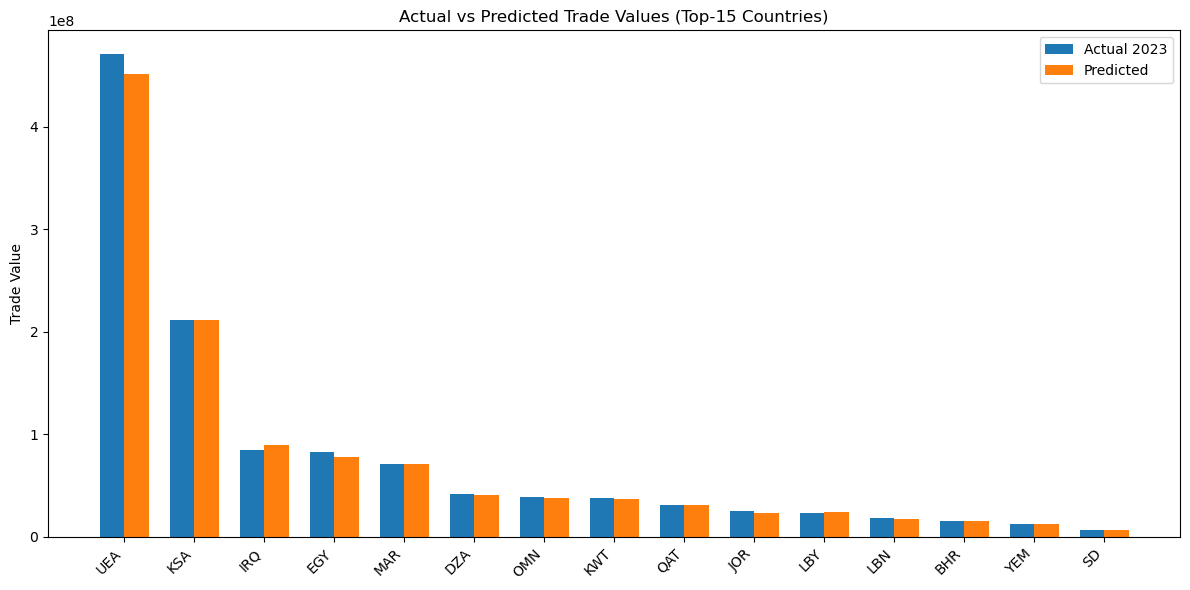

In [8]:
# ============================================================
# Predicted Trade Values by Country (Top-15 )
# ============================================================

import matplotlib.pyplot as plt

chosen_model = xgb  #As this model is performing better

# --- 2) Predicting on full dataset ---
y_pred_full = chosen_model.predict(X)

df_pred = df.copy()
df_pred["Predicted_Value"] = y_pred_full

# --- 3) Aggregating by Country ---
country_pred = df_pred.groupby("Country", as_index=False).agg(
    Actual_Value=("Value_2023","sum"),
    Predicted_Value=("Predicted_Value","sum")
)

# --- 4) Picking Top-15 by Actual + force-include Australia ---
top15 = country_pred.nlargest(15, "Actual_Value")
if "Australia" in country_pred["Country"].values and "Australia" not in top15["Country"].values:
    aus_row = country_pred[country_pred["Country"]=="Australia"]
    top15 = pd.concat([top15, aus_row], ignore_index=True)

# --- 5) Plotting ---
plt.figure(figsize=(12,6))
x = np.arange(len(top15))
width = 0.35

plt.bar(x - width/2, top15["Actual_Value"], width, label="Actual 2023")
plt.bar(x + width/2, top15["Predicted_Value"], width, label="Predicted")

plt.xticks(x, top15["Country"], rotation=45, ha="right")
plt.ylabel("Trade Value")
plt.title("Actual vs Predicted Trade Values (Top-15 Countries)")
plt.legend()
plt.tight_layout()
plt.show()


In [21]:
# ==========================================================
# XGBoost yearly predictions per Country (2023–2028)
# Table shows: Predicted Value  (YoY %)

# ==========================================================

import numpy as np
import pandas as pd

df = pd.read_csv("cleaned_trade_master (1).csv")

# Resetting index to keep alignment safe
df2 = df.copy().reset_index(drop=True)

# -- 1) Ensure an XGB pipeline exists and is fitted
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from xgboost import XGBRegressor

num_feats_all = [
    "Trade_Balance_2023","Growth_2019_2023","Growth_2022_2023",
    "World_Growth","World_Import_Rank","Avg_Distance_km",
    "Concentration","World_Import_Share","Avg_Tariff"
]
cat_feats_all = ["Country","Product","Direction"]
features = [c for c in num_feats_all + cat_feats_all if c in df2.columns]

# numeric coercion
for c in num_feats_all:
    if c in df2.columns:
        df2[c] = pd.to_numeric(df2[c], errors="coerce")
df2["Value_2023"] = pd.to_numeric(df2["Value_2023"], errors="coerce")
df2 = df2.dropna(subset=["Value_2023"]).copy()

X2 = df2[features].copy()
y2 = df2["Value_2023"].astype(float)

def build_xgb_pipeline(num_cols, cat_cols):
    num_pipe = Pipeline([("imputer", SimpleImputer(strategy="median")),
                         ("scaler", StandardScaler())])
    cat_pipe = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                         ("onehot", OneHotEncoder(handle_unknown="ignore"))])
    prep = ColumnTransformer([("num", num_pipe, num_cols),
                              ("cat", cat_pipe, cat_cols)])
    model = XGBRegressor(
        n_estimators=300, max_depth=6, learning_rate=0.06,
        subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
        random_state=42, tree_method="hist"
    )
    return Pipeline([("prep", prep), ("model", model)])

num_cols = [c for c in features if c in num_feats_all]
cat_cols = [c for c in features if c in cat_feats_all]

need_fit = False
if "xgb" not in globals():
    xgb = build_xgb_pipeline(num_cols, cat_cols)
    need_fit = True
else:
    try:
        _ = xgb.predict(X2.head(1))
    except Exception:
        need_fit = True

if need_fit:
    Xtr, Xte, ytr, yte = train_test_split(X2, y2, test_size=0.2, random_state=42)
    xgb.fit(Xtr, ytr)

# -- 2) Predicting 2023 baseline per row with XGB
yhat_2023 = xgb.predict(X2)  # aligned with df2 (reset index)

# -- 3) Building growth-blend per row (recent + trend + world), index-safe
def to_decimal(s):
    s = pd.to_numeric(s, errors="coerce")
    mask = s.abs() > 2  # likely given as whole % (e.g., 12 -> 12%)
    s.loc[mask] = s.loc[mask] / 100.0
    return s

g_recent = to_decimal(df2["Growth_2022_2023"]) if "Growth_2022_2023" in df2.columns else pd.Series(0.0, index=df2.index)
g_old    = to_decimal(df2["Growth_2019_2023"]) if "Growth_2019_2023" in df2.columns else pd.Series(0.0, index=df2.index)
g_world  = to_decimal(df2["World_Growth"])      if "World_Growth"      in df2.columns else pd.Series(0.0, index=df2.index)

g_annual_old = g_old / 4.0
g_blend = (0.6*g_recent.fillna(0.0) + 0.4*g_annual_old.fillna(0.0) + 0.3*g_world.fillna(0.0)).clip(-0.5, 1.5)

# -- 4) Vectorized projection 2023..2028 per row
years = np.array([2023, 2024, 2025, 2026, 2027, 2028])
exponents = np.arange(len(years))  # 0..5
# per-row multipliers for each year = (1+g)^k
multipliers = np.power(1.0 + g_blend.values.reshape(-1, 1), exponents.reshape(1, -1))
pred_matrix = yhat_2023.reshape(-1, 1) * multipliers  # shape: (rows, 6)

# -- 5) Assembling long DataFrame and aggregate to Country × Year
pred_long = (
    pd.DataFrame(pred_matrix, columns=years)
      .assign(Country=df2["Country"].values if "Country" in df2.columns else "Unknown")
      .melt(id_vars=["Country"], var_name="Year", value_name="Predicted_Value")
)
country_year = (pred_long.groupby(["Country","Year"], as_index=False)["Predicted_Value"].sum()
                          .sort_values(["Country","Year"]))

# -- 6) Computing YoY % growth per country from projected values
country_year["YoY_%"] = country_year.groupby("Country")["Predicted_Value"].pct_change() * 100.0

# -- 7) Formatting: "value (YoY%)" for 2024–2028; baseline shows value only
def fmt_val(v):
    try:
        return f"{v:,.0f}"
    except:
        return str(v)

def fmt_pct(p):
    return "" if pd.isna(p) else f"{p:.1f}%"

country_year["Display"] = np.where(
    country_year["Year"].eq(2023),
    country_year["Predicted_Value"].map(fmt_val),
    country_year.apply(lambda r: f"{fmt_val(r['Predicted_Value'])} ({fmt_pct(r['YoY_%'])})", axis=1)
)

# Pivoting to wide table
table = (country_year.pivot(index="Country", columns="Year", values="Display")
         .reindex(columns=years))

# Sorting rows by 2023 baseline descending
baseline = country_year[country_year["Year"].eq(2023)].set_index("Country")["Predicted_Value"]
table = table.loc[baseline.sort_values(ascending=False).index]

display(table.fillna(""))


# -----------------------------
# 8) Save CSVs for Power BI
# -----------------------------

# (A) Tidy numeric file: Country × Year with numeric columns
country_year_numeric = (
    country_year[["Country", "Year", "Predicted_Value", "YoY_%"]]
    .sort_values(["Country", "Year"])
    .copy()
)

# Round for readability (keeps numbers numeric for DAX/measures)
country_year_numeric["Predicted_Value"] = country_year_numeric["Predicted_Value"].round(0)
country_year_numeric["YoY_%"] = country_year_numeric["YoY_%"].round(1)

country_year_numeric.to_csv("xgb_country_year_2023_2028_numeric.csv", index=False)

# (B) Pivoted pretty table with "value (YoY%)" strings (optional)
table_out = table.fillna("")
table_out.to_csv("xgb_country_year_2023_2028_display.csv")



Year,2023,2024,2025,2026,2027,2028
Country,,,,,,
UEA,"426,419,003","495,663,119 (16.2%)","592,041,060 (19.4%)","732,865,299 (23.8%)","955,045,208 (30.3%)","1,338,032,919 (40.1%)"
KSA,"200,699,339","228,475,624 (13.8%)","270,884,860 (18.6%)","336,192,225 (24.1%)","443,056,442 (31.8%)","632,516,759 (42.8%)"
IRQ,"89,330,585","101,341,038 (13.4%)","117,347,360 (15.8%)","139,242,085 (18.7%)","170,718,366 (22.6%)","219,049,478 (28.3%)"
EGY,"77,681,440","77,739,000 (0.1%)","80,385,062 (3.4%)","86,740,374 (7.9%)","98,945,104 (14.1%)","120,857,088 (22.1%)"
MAR,"67,783,736","73,092,068 (7.8%)","82,617,267 (13.0%)","100,261,071 (21.4%)","135,006,577 (34.7%)","207,501,712 (53.7%)"
DZA,"41,109,766","47,349,612 (15.2%)","56,343,732 (19.0%)","69,497,058 (23.3%)","89,154,253 (28.3%)","119,387,375 (33.9%)"
OMN,"36,897,563","35,039,854 (-5.0%)","38,665,290 (10.3%)","49,796,278 (28.8%)","74,554,811 (49.7%)","127,255,507 (70.7%)"
KWT,"36,896,988","42,224,381 (14.4%)","51,549,870 (22.1%)","68,968,715 (33.8%)","103,605,527 (50.2%)","175,928,865 (69.8%)"
QAT,"30,434,532","32,116,775 (5.5%)","38,965,351 (21.3%)","55,931,207 (43.5%)","95,739,958 (71.2%)","189,775,542 (98.2%)"


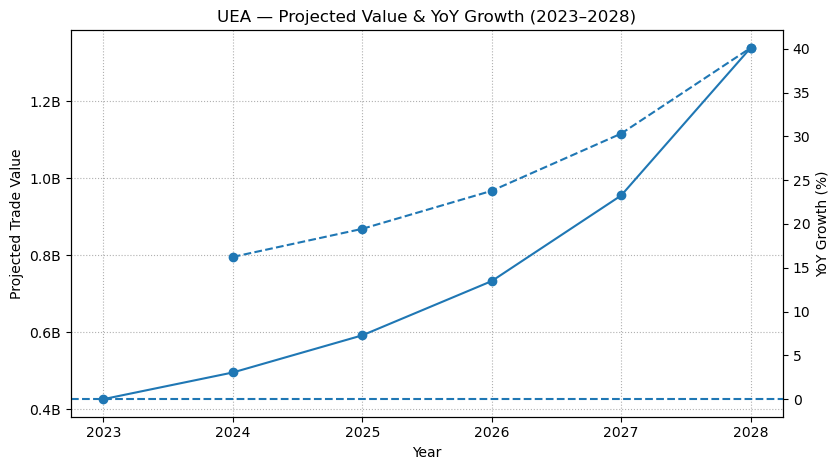

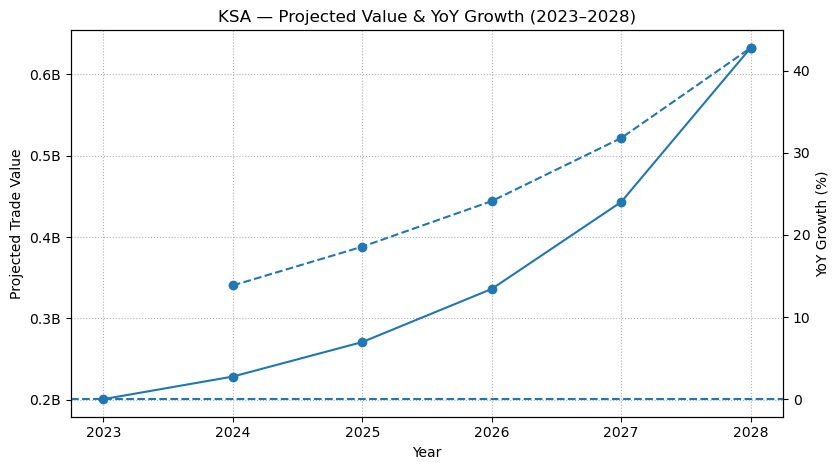

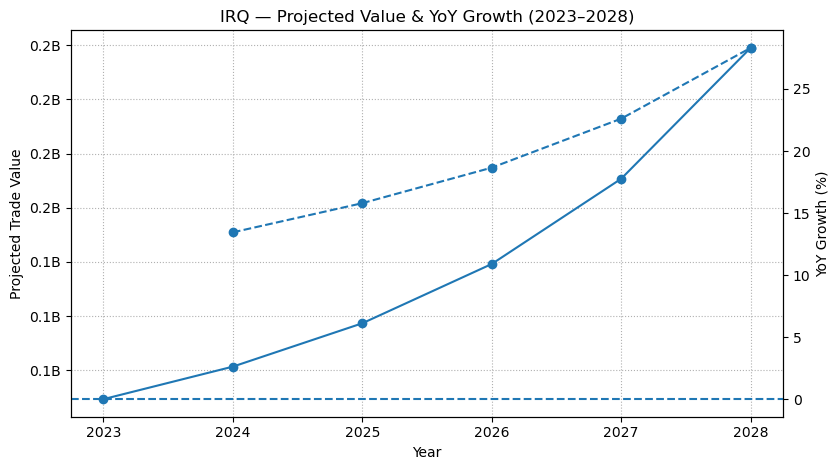

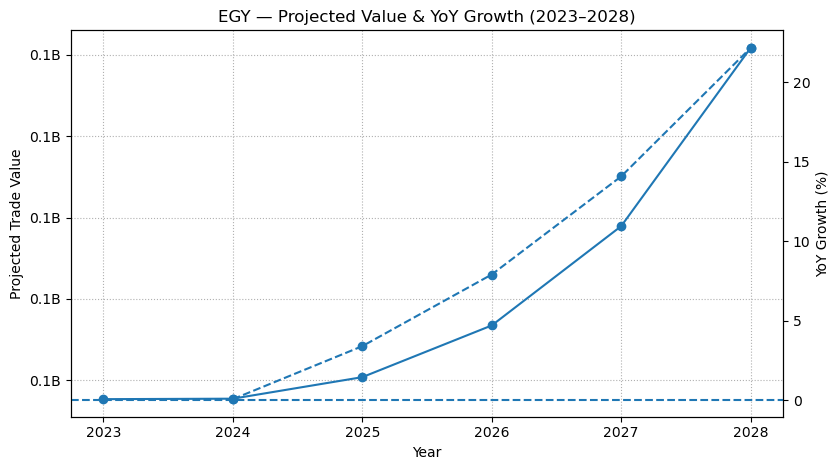

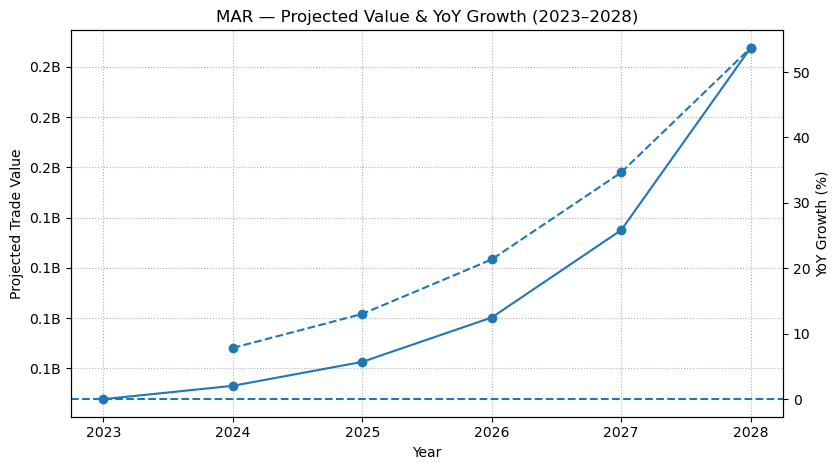

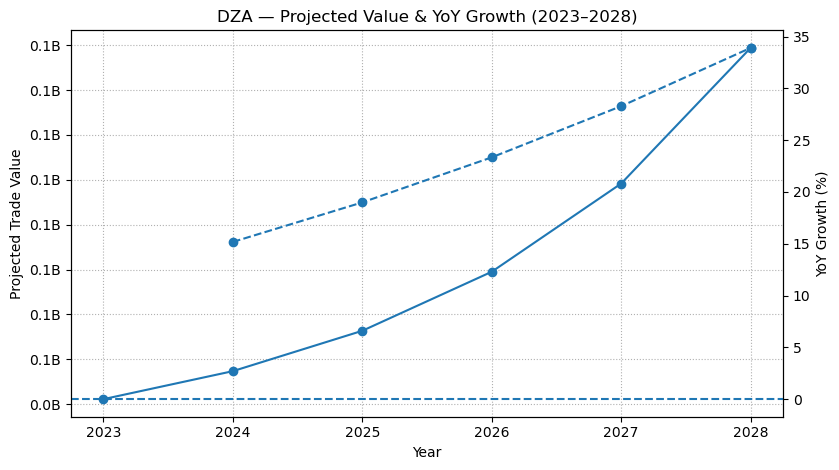

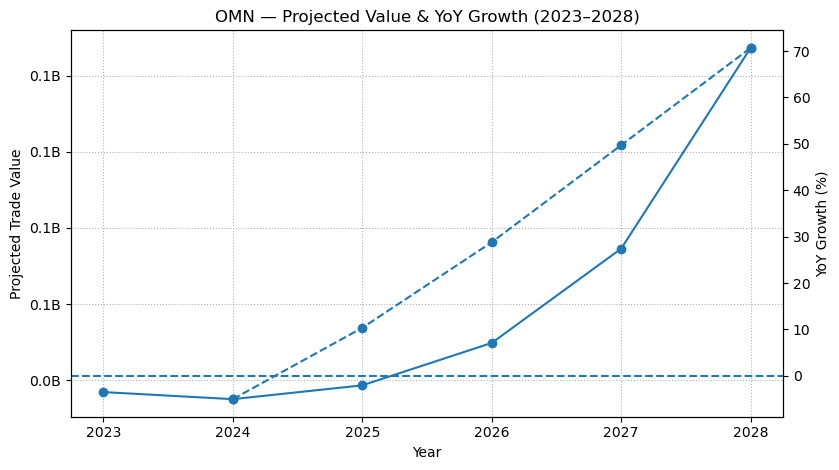

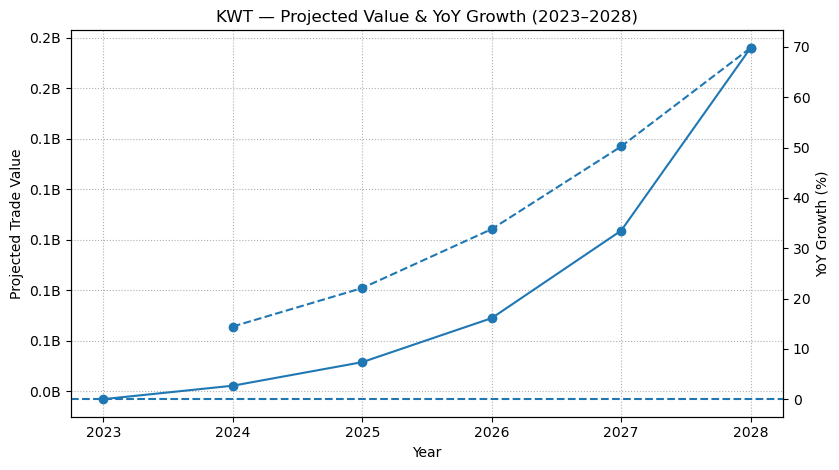

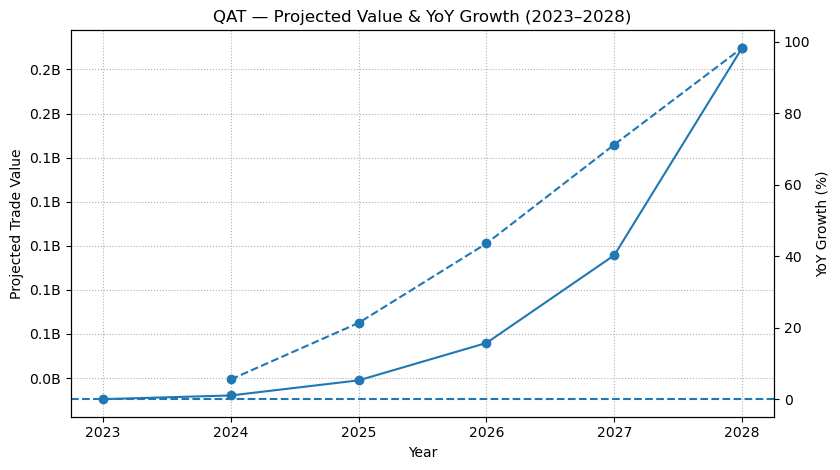

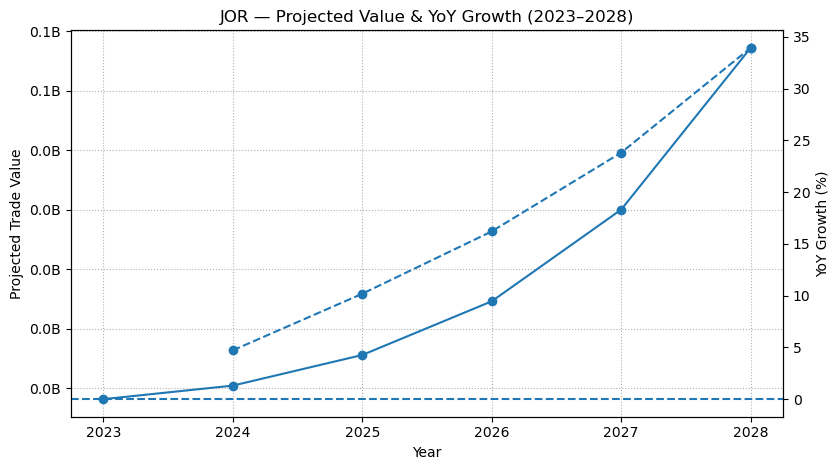

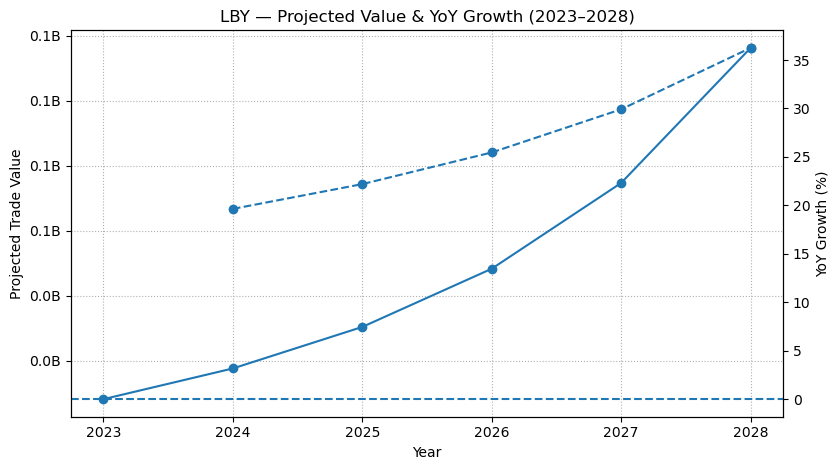

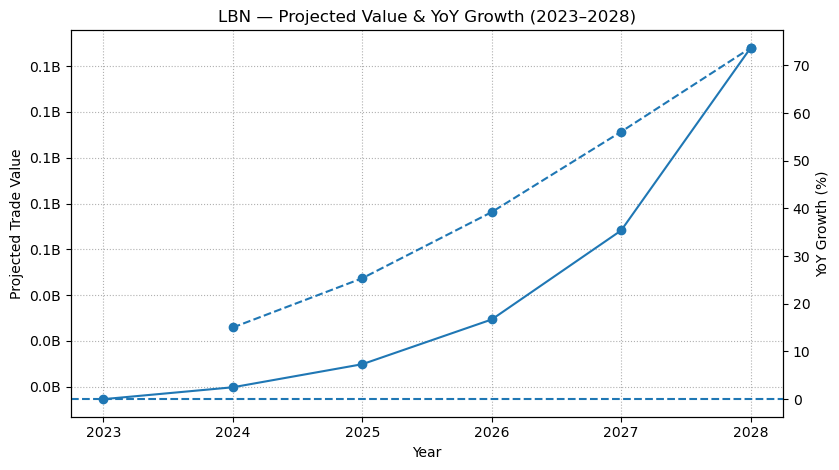

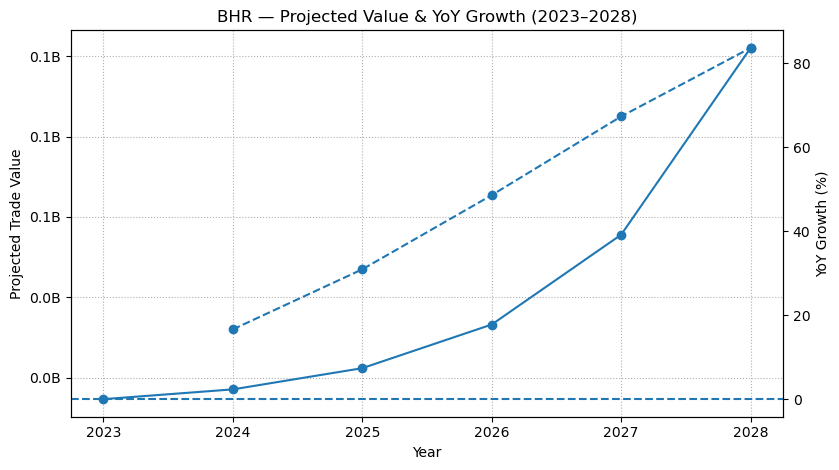

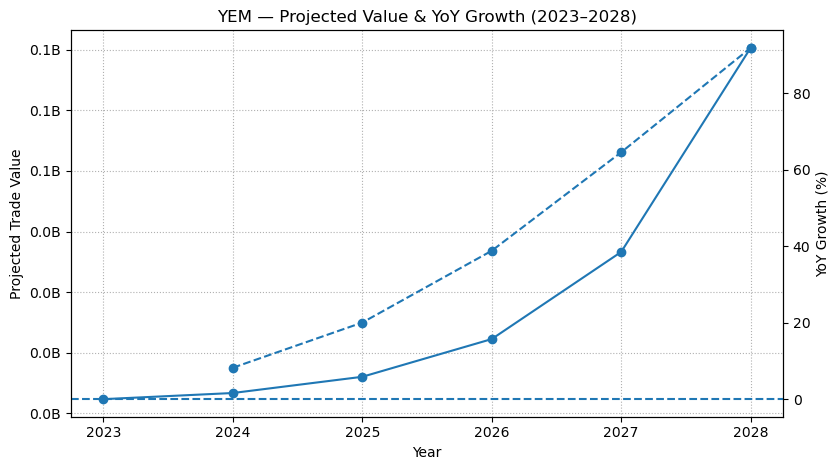

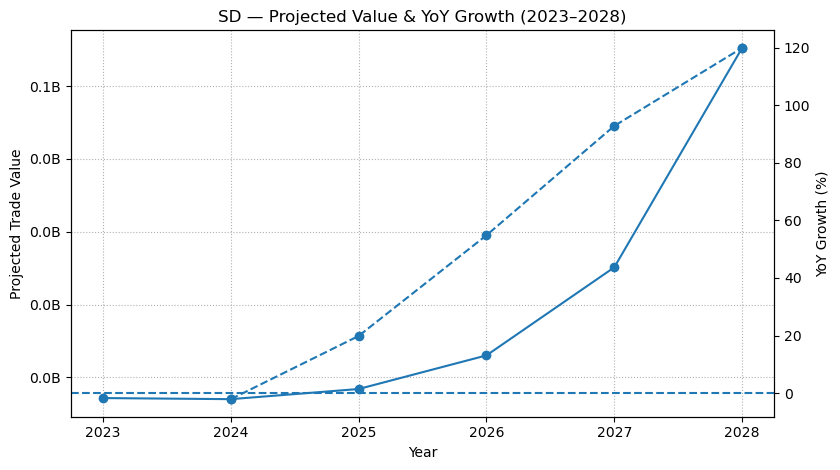

In [19]:
# ==========================================================
# One chart per country (clean): Value line + YoY% (dual axis)
# XGBoost baseline (2023) + growth-blend for 2024–2028
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

df = pd.read_csv("cleaned_trade_master (1).csv")

if "Value_2023" not in df.columns:
    raise ValueError("Column 'Value_2023' is required.")
if "Country" not in df.columns:
    raise ValueError("Column 'Country' is required for per-country charts.")

df2 = df.copy().reset_index(drop=True)
df2["Value_2023"] = pd.to_numeric(df2["Value_2023"], errors="coerce")
df2 = df2.dropna(subset=["Value_2023"]).copy()

# --------------------
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from xgboost import XGBRegressor

num_feats_all = [
    "Trade_Balance_2023","Growth_2019_2023","Growth_2022_2023",
    "World_Growth","World_Import_Rank","Avg_Distance_km",
    "Concentration","World_Import_Share","Avg_Tariff"
]
cat_feats_all = ["Country","Product","Direction"]
features = [c for c in num_feats_all + cat_feats_all if c in df2.columns]

for c in num_feats_all:
    if c in df2.columns:
        df2[c] = pd.to_numeric(df2[c], errors="coerce")

X2 = df2[features].copy()

def build_xgb_pipeline(num_cols, cat_cols):
    num_pipe = Pipeline([("imputer", SimpleImputer(strategy="median")),
                         ("scaler", StandardScaler())])
    cat_pipe = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                         ("onehot", OneHotEncoder(handle_unknown="ignore"))])
    prep = ColumnTransformer([("num", num_pipe, num_cols),
                              ("cat", cat_pipe, cat_cols)])
    model = XGBRegressor(
        n_estimators=300, max_depth=6, learning_rate=0.06,
        subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
        random_state=42, tree_method="hist"
    )
    return Pipeline([("prep", prep), ("model", model)])

num_cols = [c for c in features if c in num_feats_all]
cat_cols = [c for c in features if c in cat_feats_all]

need_fit = False
if "xgb" not in globals():
    xgb = build_xgb_pipeline(num_cols, cat_cols)
    need_fit = True
else:
    try:
        _ = xgb.predict(X2.head(1))
    except Exception:
        need_fit = True

if need_fit:
    Xtr, Xte, ytr, yte = train_test_split(X2, df2["Value_2023"].astype(float), test_size=0.2, random_state=42)
    xgb.fit(Xtr, ytr)

# ---------- 2) Building projections 2023–2028 ----------
yhat_2023 = xgb.predict(X2)  # predicted baseline per row (2023)

def to_decimal(s):
    s = pd.to_numeric(s, errors="coerce")
    mask = s.abs() > 2  # treat as whole % if magnitude >2
    s.loc[mask] = s.loc[mask] / 100.0
    return s

g_recent = to_decimal(df2["Growth_2022_2023"]) if "Growth_2022_2023" in df2 else pd.Series(0.0, index=df2.index)
g_old    = to_decimal(df2["Growth_2019_2023"]) if "Growth_2019_2023" in df2 else pd.Series(0.0, index=df2.index)
g_world  = to_decimal(df2["World_Growth"])      if "World_Growth"      in df2 else pd.Series(0.0, index=df2.index)

g_blend  = (0.6*g_recent.fillna(0.0) + 0.4*(g_old.fillna(0.0)/4.0) + 0.3*g_world.fillna(0.0)).clip(-0.5, 1.5)

years = np.array([2023, 2024, 2025, 2026, 2027, 2028])
k = np.arange(len(years))  # 0..5
multipliers = np.power(1.0 + g_blend.values.reshape(-1, 1), k.reshape(1, -1))
pred_matrix = yhat_2023.reshape(-1, 1) * multipliers  # per-row × years

pred_long = (
    pd.DataFrame(pred_matrix, columns=years)
      .assign(Country=df2["Country"].values)
      .melt(id_vars=["Country"], var_name="Year", value_name="Predicted_Value")
)
country_year = (pred_long.groupby(["Country","Year"], as_index=False)["Predicted_Value"].sum()
                          .sort_values(["Country","Year"]))
country_year["YoY_%"] = country_year.groupby("Country")["Predicted_Value"].pct_change() * 100.0

# ---------- 3) ploting one chart per country ----------
def plot_country(country_name: str):
    sub = country_year[country_year["Country"] == country_name].sort_values("Year")
    if sub.empty:
        print(f"No data for {country_name}")
        return
    fig, ax1 = plt.subplots(figsize=(8.5, 4.8))
    ax1.plot(sub["Year"], sub["Predicted_Value"], marker="o")
    ax1.set_xlabel("Year")
    ax1.set_ylabel("Projected Trade Value")
    ax1.set_title(f"{country_name} — Projected Value & YoY Growth (2023–2028)")
    ax1.grid(True, linestyle=":")

    ax1.yaxis.set_major_formatter(
        mtick.FuncFormatter(lambda x, _: f'{x*1e-9:.1f}B')
    )

    ax2 = ax1.twinx()
    ax2.plot(sub["Year"], sub["YoY_%"], marker="o", linestyle="--")
    ax2.set_ylabel("YoY Growth (%)")
    ax2.axhline(0, linestyle="--")

    fig.tight_layout()
    plt.show()
    

def plot_topN_countries(N=15, include_australia=True):
    base2023 = country_year[country_year["Year"]==2023].sort_values("Predicted_Value", ascending=False)
    top_list = base2023.head(N)["Country"].tolist()
    if include_australia and ("Australia" in country_year["Country"].unique()) and ("Australia" not in top_list):
        top_list.append("Australia")
    for c in top_list:
        plot_country(c)

# ---------- 4) Generating one chart per country ----------
plot_topN_countries(N=15, include_australia=True)

# Example to plot a single country manually:
# plot_country("Australia")
